# KNN Classification - Election Data

## Project Description
This project uses the **K-Nearest Neighbors (KNN)** algorithm to predict voter preference between **Labour** and **Conservative** based on demographic and opinion-based variables such as age, economic condition, leader ratings, Europe opinion, political knowledge, and gender.

This project demonstrates customer/voter segmentation, classification modelling, performance evaluation, and insight generation for decision-making.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

## 2. Load Dataset

In [2]:
df = pd.read_excel('Election_Data.xlsx', sheet_name='Election_Dataset_Two Classes')
df.head()

,Unnamed: 0,vote,age,economic.cond.national,economic.cond.household,Blair,Hague,Europe,political.knowledge,gender
0,1,Labour,43,3,3,4,1,2,2,female
1,2,Labour,36,4,4,4,4,5,2,male
2,3,Labour,35,4,4,5,2,3,2,male
3,4,Labour,24,4,2,2,1,4,0,female
4,5,Labour,41,2,2,1,1,6,2,male


## 3. Basic Data Understanding

In [3]:
print("Dataset Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())
print("\nTarget Distribution:")
print(df['vote'].value_counts())

Dataset Shape: (1525, 10)

Data Types:
Unnamed: 0                  int64
vote                       object
age                         int64
economic.cond.national      int64
economic.cond.household     int64
Blair                       int64
Hague                       int64
Europe                      int64
political.knowledge         int64
gender                     object
dtype: object

Missing Values:
Unnamed: 0                 0
vote                       0
age                        0
economic.cond.national     0
economic.cond.household    0
Blair                      0
Hague                      0
Europe                     0
political.knowledge        0
gender                     0
dtype: int64

Duplicate Rows: 0

Target Distribution:
vote
Labour          1063
Conservative     462
Name: count, dtype: int64


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,1525.0,763.000000,440.373894,1.0,382.0,763.0,1144.0,1525.0
age,1525.0,54.182295,15.711209,24.0,41.0,53.0,67.0,93.0
economic.cond.national,1525.0,3.245902,0.880969,1.0,3.0,3.0,4.0,5.0
economic.cond.household,1525.0,3.140328,0.929951,1.0,3.0,3.0,4.0,5.0
Blair,1525.0,3.334426,1.174824,1.0,2.0,4.0,4.0,5.0
Hague,1525.0,2.746885,1.230703,1.0,2.0,2.0,4.0,5.0
Europe,1525.0,6.728525,3.297538,1.0,4.0,6.0,10.0,11.0
political.knowledge,1525.0,1.542295,1.083315,0.0,0.0,2.0,2.0,3.0


## 4. Data Cleaning

The `Unnamed: 0` column is only an index-like column, so it is removed because it does not add predictive value.

In [5]:
df = df.drop(columns=['Unnamed: 0'])
df.head()

,vote,age,economic.cond.national,economic.cond.household,Blair,Hague,Europe,political.knowledge,gender
0,Labour,43,3,3,4,1,2,2,female
1,Labour,36,4,4,4,4,5,2,male
2,Labour,35,4,4,5,2,3,2,male
3,Labour,24,4,2,2,1,4,0,female
4,Labour,41,2,2,1,1,6,2,male


## 5. Exploratory Data Analysis

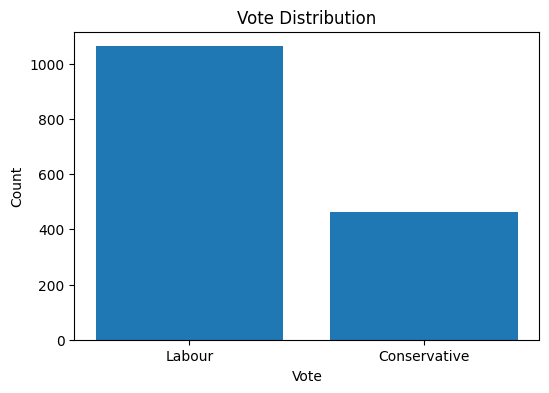

vote
Labour          1063
Conservative     462
Name: count, dtype: int64

In [6]:
# Target distribution
vote_counts = df['vote'].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(vote_counts.index, vote_counts.values)
plt.title('Vote Distribution')
plt.xlabel('Vote')
plt.ylabel('Count')
plt.show()

vote_counts

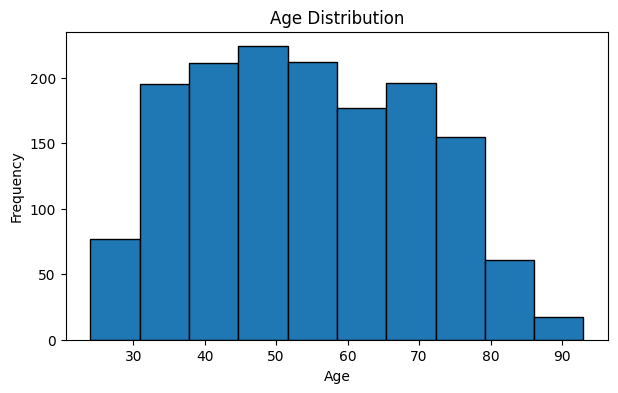

In [7]:
# Age distribution
plt.figure(figsize=(7, 4))
plt.hist(df['age'], bins=10, edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

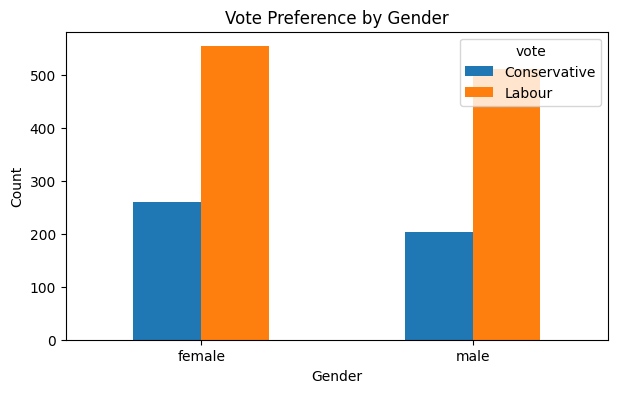

vote,Conservative,Labour
gender,,
female,259,553
male,203,510


In [8]:
# Gender-wise vote distribution
gender_vote = pd.crosstab(df['gender'], df['vote'])
gender_vote.plot(kind='bar', figsize=(7, 4))
plt.title('Vote Preference by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

gender_vote

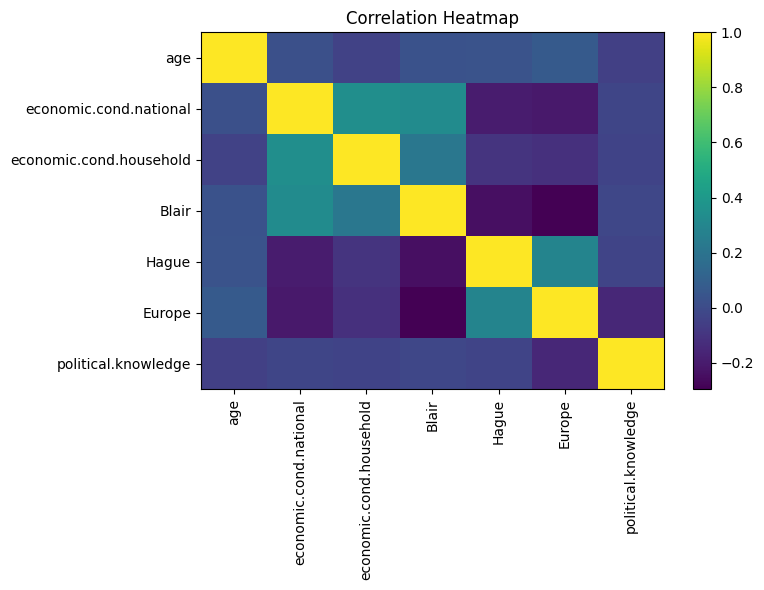

,age,economic.cond.national,economic.cond.household,Blair,Hague,Europe,political.knowledge
age,1.000000,0.018567,-0.041587,0.030218,0.034626,0.068880,-0.048490
economic.cond.national,0.018567,1.000000,0.346303,0.326878,-0.199766,-0.209429,-0.023624
economic.cond.household,-0.041587,0.346303,1.000000,0.215273,-0.101956,-0.114885,-0.037810
Blair,0.030218,0.326878,0.215273,1.000000,-0.243210,-0.296162,-0.020917
Hague,0.034626,-0.199766,-0.101956,-0.243210,1.000000,0.287350,-0.030354
Europe,0.068880,-0.209429,-0.114885,-0.296162,0.287350,1.000000,-0.152364
political.knowledge,-0.048490,-0.023624,-0.037810,-0.020917,-0.030354,-0.152364,1.000000


In [9]:
# Correlation among numeric variables
numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr, aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

corr

## 6. Feature and Target Selection

The target variable is `vote`. All other columns are used as input features.

In [10]:
X = df.drop(columns='vote')
y = df['vote']

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric Features:", numeric_features)
print("Categorical Features:", categorical_features)

Numeric Features: ['age', 'economic.cond.national', 'economic.cond.household', 'Blair', 'Hague', 'Europe', 'political.knowledge']
Categorical Features: ['gender']


## 7. Train-Test Split and Preprocessing

KNN is distance-based, so scaling numeric features is very important.  
To avoid data leakage, scaling and encoding are fitted only on the training data using a pipeline.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ]
)

## 8. Model Comparison for Different K Values

In [12]:
results = []

for k in [3, 5, 7, 9, 11, 15, 21, 31]:
    model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('knn', KNeighborsClassifier(n_neighbors=k, weights='uniform'))
    ])

    model.fit(X_train, y_train)
    train_accuracy = model.score(X_train, y_train)
    test_accuracy = model.score(X_test, y_test)

    results.append({
        'K': k,
        'Train Accuracy': round(train_accuracy, 4),
        'Test Accuracy': round(test_accuracy, 4)
    })

results_df = pd.DataFrame(results)
results_df

,K,Train Accuracy,Test Accuracy
0,3,0.8744,0.8231
1,5,0.8660,0.8428
2,7,0.8510,0.8384
3,9,0.8557,0.8319
4,11,0.8491,0.8253
5,15,0.8369,0.8319
6,21,0.8313,0.8231
7,31,0.8266,0.8253


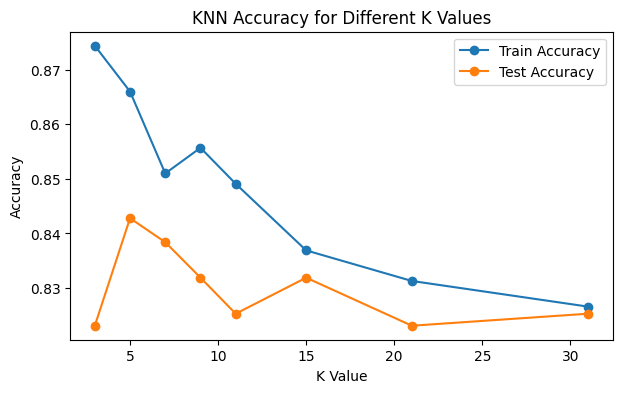

In [13]:
plt.figure(figsize=(7, 4))
plt.plot(results_df['K'], results_df['Train Accuracy'], marker='o', label='Train Accuracy')
plt.plot(results_df['K'], results_df['Test Accuracy'], marker='o', label='Test Accuracy')
plt.title('KNN Accuracy for Different K Values')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## 9. Final KNN Model

Based on the comparison, `K = 5` gives strong test accuracy while keeping the train-test gap acceptable.

In [14]:
final_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('knn', KNeighborsClassifier(n_neighbors=5, weights='uniform'))
])

final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)

train_accuracy = final_model.score(X_train, y_train)
test_accuracy = accuracy_score(y_test, y_pred)

print("Train Accuracy:", round(train_accuracy, 4))
print("Test Accuracy:", round(test_accuracy, 4))

Train Accuracy: 0.866
Test Accuracy: 0.8428


## 10. Model Evaluation

Confusion Matrix:
[[100  39]
 [ 33 286]]


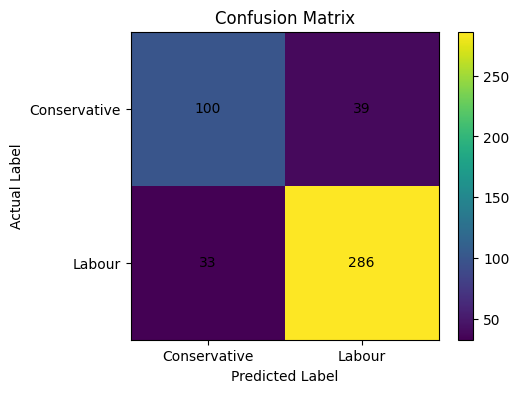


Classification Report:
              precision    recall  f1-score   support

Conservative       0.75      0.72      0.74       139
      Labour       0.88      0.90      0.89       319

    accuracy                           0.84       458
   macro avg       0.82      0.81      0.81       458
weighted avg       0.84      0.84      0.84       458



In [15]:
labels = ['Conservative', 'Labour']
cm = confusion_matrix(y_test, y_pred, labels=labels)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.colorbar()
plt.xticks(range(len(labels)), labels)
plt.yticks(range(len(labels)), labels)
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix')

for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

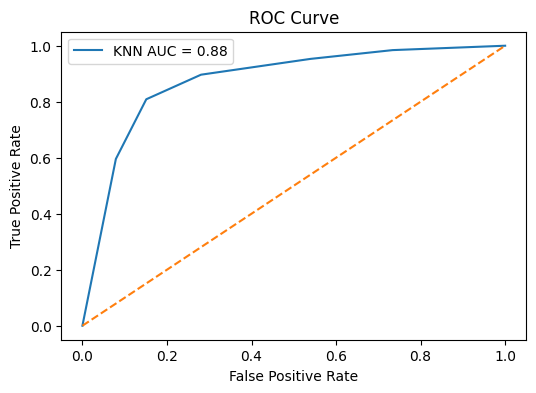

ROC-AUC Score: 0.8763


In [16]:
# ROC-AUC for Labour class
class_labels = list(final_model.named_steps['knn'].classes_)
labour_index = class_labels.index('Labour')

y_test_binary = (y_test == 'Labour').astype(int)
labour_probability = y_proba[:, labour_index]

auc_score = roc_auc_score(y_test_binary, labour_probability)
fpr, tpr, thresholds = roc_curve(y_test_binary, labour_probability)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'KNN AUC = {auc_score:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

print("ROC-AUC Score:", round(auc_score, 4))

## Observations

- The dataset contains **1,525 records** and no missing values.
- There are **8 duplicate rows**, which are minor and do not heavily affect the project.
- The target variable is imbalanced: Labour has more records than Conservative.
- KNN performs better after applying feature scaling because it is a distance-based algorithm.
- The original notebook had some issues:
  - Scaling was done before train-test split, which can cause data leakage.
  - The notebook failed at one visualization cell due to a plotting issue.
  - `weights='distance'` caused very high training accuracy, making the model look overfitted.
  - Different train-test splits were used for different K values, so comparison was not fully fair.
- After correction, `K = 5` gives around **84% test accuracy**.
- The model predicts Labour better than Conservative because Labour has more observations in the dataset.

## Conclusion

The KNN model is suitable for predicting voter preference using demographic and opinion-based features. The project shows how classification models can support campaign strategy, voter segmentation, and decision-making.

The final model gives good performance with around **84% test accuracy**. However, because the dataset is imbalanced, accuracy alone should not be used. Precision, recall, F1-score, and the confusion matrix should also be reviewed, especially for the Conservative class.